In [1]:
import os
dir_path = os.getcwd()
print("The directory of this script is:", dir_path)
root_path = os.path.dirname(dir_path)
print("The root directory is:", root_path)

The directory of this script is: c:\Users\HP\Desktop\Projects\NodeRAG\testing
The root directory is: c:\Users\HP\Desktop\Projects\NodeRAG


In [2]:
import pandas as pd
medical_questions_answered_loaded = pd.read_parquet("data/medical_questions_answered.parquet")
medical_questions_answered_loaded

,id,source,question,answer,question_type,evidence,evidence_relations,LLM_answer,LLM_context,LLM_tokens
0,Medical-73586ddc,Medical,What is the most common type of skin cancer?,Basal cell carcinoma (BCC) is the most common ...,Fact Retrieval,Basal cell carcinoma (BCC) is the most common ...,Basal cell carcinoma (BCC) is the most common ...,"Basal cell skin cancer, also known as basal ce...",Squamous cell skin cancer (CSCC) is the second...,24381.0
1,Medical-a8bad1cf,Medical,From which cell type does basal cell carcinoma...,Basal cell carcinoma arises from basal cells i...,Fact Retrieval,Basal cell carcinoma arises from basal cells.;...,BCC arises from basal cells in the lower part ...,Basal cell carcinoma arises when basal cells i...,"Basal cell skin cancer, also known as basal ce...",4113.0
2,Medical-422500d5,Medical,Which anatomical locations are most commonly a...,BCC most commonly develops in sun-exposed area...,Fact Retrieval,BCC most commonly develops in sun-exposed area...,BCC most commonly develops in sun-exposed area...,Basal cell carcinoma most commonly affects sun...,Basal cell skin cancer can affect anyone but i...,3514.0
3,Medical-6d2a190d,Medical,What is the primary risk factor for basal cell...,UV radiation exposure is a primary risk factor...,Fact Retrieval,UV radiation exposure is a primary risk factor...,UV radiation exposure is a primary risk factor...,The primary risk factor for basal cell carcino...,Basal cell skin cancer can affect anyone but i...,6428.0
4,Medical-5ad931db,Medical,How does fair skin affect the risk of developi...,Fair skin increases the risk of BCC.,Fact Retrieval,Fair skin increases the risk of BCC.,"Fair skin, light hair, and light eye color inc...",Fair skin increases the risk of developing Bas...,Basal cell skin cancer can affect anyone but i...,8562.0
...,...,...,...,...,...,...,...,...,...,...
2057,Medical-83c906e0,Medical,You are an oncologist preparing a referral let...,"Dear Multidisciplinary Team,\n\nI am referring...",Creative Generation,The patient is a 45-year-old female.; The pati...,Invasive ductal carcinoma is the most common t...,This 45-year-old woman has been diagnosed with...,"An Oncologist, often known simply as a cancer ...",36469.0
2058,Medical-d168a555,Medical,Imagine you are a medical intern tasked with w...,Discharge Summary:\n\nDiagnosis: Stage III inf...,Creative Generation,The diagnosis is Stage III inflammatory breast...,"Inflammatory breast cancer (IBC) is a rare, ag...",**Diagnosis:**\nPatient was diagnosed with Inf...,This section lists various topics related to b...,25434.0
2059,Medical-fe801cec,Medical,You are a patient advocate tasked with draftin...,Public Health Notice: Protect Yourself—Know th...,Creative Generation,Breast cancer is a carcinoma that starts in th...,Breast cancer is a carcinoma that starts in th...,## Public Health Notice: Understanding Breast ...,Breast cancer arises from epithelial cells (ce...,13936.0
2060,Medical-9210668e,Medical,Transform the clinical facts on metastatic bre...,SOAP Progress Note\n\nSubjective: The patient ...,Creative Generation,The patient reports persistent bone pain.; The...,Metastatic breast cancer (MBC) is breast cance...,**S: Subjective**\nPatient reports distress an...,Here are distinct categories of high-level inf...,29012.0


In [46]:
sep = "\n\n" + "-"*100 + "\n\n"
medical_questions_answered_loaded["Context_nodes"] = medical_questions_answered_loaded["LLM_context"].apply(lambda x: len(x.split(sep)))

In [48]:
min_all = round(medical_questions_answered_loaded['LLM_tokens'].min())
max_all = round(medical_questions_answered_loaded['LLM_tokens'].max())
avg_all = round(medical_questions_answered_loaded['LLM_tokens'].mean())
total_all = round(medical_questions_answered_loaded['LLM_tokens'].sum())

print("Minimum tokens used:", f"{min_all:,}")
print("Maximum tokens used:", f"{max_all:,}")
print("Average tokens used:", f"{avg_all:,}")
print("Total tokens used:", f"{total_all:,}")

print(sep)

min_nodes_all = round(medical_questions_answered_loaded['Context_nodes'].min())
max_nodes_all = round(medical_questions_answered_loaded['Context_nodes'].max())
avg_nodes_all = round(medical_questions_answered_loaded['Context_nodes'].mean())
total_nodes_all = round(medical_questions_answered_loaded['Context_nodes'].sum())

print("Minimum context nodes used:", f"{min_nodes_all:,}")
print("Maximum context nodes used:", f"{max_nodes_all:,}")
print("Average context nodes used:", f"{avg_nodes_all:,}")
print("Total context nodes used:", f"{total_nodes_all:,}")

Minimum tokens used: 1,474
Maximum tokens used: 43,777
Average tokens used: 14,344
Total tokens used: 29,577,789


----------------------------------------------------------------------------------------------------


Minimum context nodes used: 11
Maximum context nodes used: 61
Average context nodes used: 25
Total context nodes used: 50,800


In [49]:
min_retrieval = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Fact Retrieval"]['LLM_tokens'].min())
max_retrieval = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Fact Retrieval"]['LLM_tokens'].max())
avg_retrieval = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Fact Retrieval"]['LLM_tokens'].mean())
total_retrieval = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Fact Retrieval"]['LLM_tokens'].sum())

print("Minimum tokens used:", f"{min_retrieval:,}")
print("Maximum tokens used:", f"{max_retrieval:,}")
print("Average tokens used:", f"{avg_retrieval:,}")
print("Total tokens used:", f"{total_retrieval:,}")

print(sep)

min_nodes_retrieval = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Fact Retrieval"]['Context_nodes'].min())
max_nodes_retrieval = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Fact Retrieval"]['Context_nodes'].max())
avg_nodes_retrieval = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Fact Retrieval"]['Context_nodes'].mean())
total_nodes_retrieval = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Fact Retrieval"]['Context_nodes'].sum())

print("Minimum context nodes used:", f"{min_nodes_retrieval:,}")
print("Maximum context nodes used:", f"{max_nodes_retrieval:,}")
print("Average context nodes used:", f"{avg_nodes_retrieval:,}")
print("Total context nodes used:", f"{total_nodes_retrieval:,}")

Minimum tokens used: 1,474
Maximum tokens used: 35,574
Average tokens used: 12,030
Total tokens used: 13,208,490


----------------------------------------------------------------------------------------------------


Minimum context nodes used: 12
Maximum context nodes used: 61
Average context nodes used: 24
Total context nodes used: 26,102


In [ ]:
min_complex = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Complex Reasoning"]['LLM_tokens'].min())
max_complex = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Complex Reasoning"]['LLM_tokens'].max())
avg_complex = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Complex Reasoning"]['LLM_tokens'].mean())
total_complex = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Complex Reasoning"]['LLM_tokens'].sum())

print("Minimum tokens used:", f"{min_complex:,}")
print("Maximum tokens used:", f"{max_complex:,}")
print("Average tokens used:", f"{avg_complex:,}")
print("Total tokens used:", f"{total_complex:,}")

print(sep)

min_nodes_complex = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Complex Reasoning"]['Context_nodes'].min())
max_nodes_complex = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Complex Reasoning"]['Context_nodes'].max())
avg_nodes_complex = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Complex Reasoning"]['Context_nodes'].mean())
total_nodes_complex = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Complex Reasoning"]['Context_nodes'].sum())

print("Minimum context nodes used:", f"{min_nodes_complex:,}")
print("Maximum context nodes used:", f"{max_nodes_complex:,}")
print("Average context nodes used:", f"{avg_nodes_complex:,}")
print("Total context nodes used:", f"{total_nodes_complex:,}")

Minimum tokens used: 1,558
Maximum tokens used: 32,679
Average tokens used: 15,781
Total tokens used: 8,032,573


----------------------------------------------------------------------------------------------------


Minimum context nodes used: 11
Maximum context nodes used: 41
Average context nodes used: 25
Total context nodes used: 12,793


In [51]:
min_summary = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Contextual Summarize"]['LLM_tokens'].min())
max_summary = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Contextual Summarize"]['LLM_tokens'].max())
avg_summary = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Contextual Summarize"]['LLM_tokens'].mean())
total_summary = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Contextual Summarize"]['LLM_tokens'].sum())

print("Minimum tokens used:", f"{min_summary:,}")
print("Maximum tokens used:", f"{max_summary:,}")
print("Average tokens used:", f"{avg_summary:,}")
print("Total tokens used:", f"{total_summary:,}")

print(sep)

min_nodes_summary = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Contextual Summarize"]['Context_nodes'].min())
max_nodes_summary = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Contextual Summarize"]['Context_nodes'].max())
avg_nodes_summary = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Contextual Summarize"]['Context_nodes'].mean())
total_nodes_summary = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Contextual Summarize"]['Context_nodes'].sum())

print("Minimum context nodes used:", f"{min_nodes_summary:,}")
print("Maximum context nodes used:", f"{max_nodes_summary:,}")
print("Average context nodes used:", f"{avg_nodes_summary:,}")
print("Total context nodes used:", f"{total_nodes_summary:,}")

Minimum tokens used: 2,370
Maximum tokens used: 34,825
Average tokens used: 14,735
Total tokens used: 4,258,324


----------------------------------------------------------------------------------------------------


Minimum context nodes used: 12
Maximum context nodes used: 38
Average context nodes used: 24
Total context nodes used: 6,909


In [52]:
min_generation = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Creative Generation"]['LLM_tokens'].min())
max_generation = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Creative Generation"]['LLM_tokens'].max())
avg_generation = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Creative Generation"]['LLM_tokens'].mean())
total_generation = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Creative Generation"]['LLM_tokens'].sum())

print("Minimum tokens used:", f"{min_generation:,}")
print("Maximum tokens used:", f"{max_generation:,}")
print("Average tokens used:", f"{avg_generation:,}")
print("Total tokens used:", f"{total_generation:,}")

print(sep)

min_nodes_generation = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Creative Generation"]['Context_nodes'].min())
max_nodes_generation = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Creative Generation"]['Context_nodes'].max())
avg_nodes_generation = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Creative Generation"]['Context_nodes'].mean())
total_nodes_generation = round(medical_questions_answered_loaded[medical_questions_answered_loaded["question_type"] == "Creative Generation"]['Context_nodes'].sum())

print("Minimum context nodes used:", f"{min_nodes_generation:,}")
print("Maximum context nodes used:", f"{max_nodes_generation:,}")
print("Average context nodes used:", f"{avg_nodes_generation:,}")
print("Total context nodes used:", f"{total_nodes_generation:,}")

Minimum tokens used: 4,444
Maximum tokens used: 43,777
Average tokens used: 24,569
Total tokens used: 4,078,402


----------------------------------------------------------------------------------------------------


Minimum context nodes used: 20
Maximum context nodes used: 45
Average context nodes used: 30
Total context nodes used: 4,996


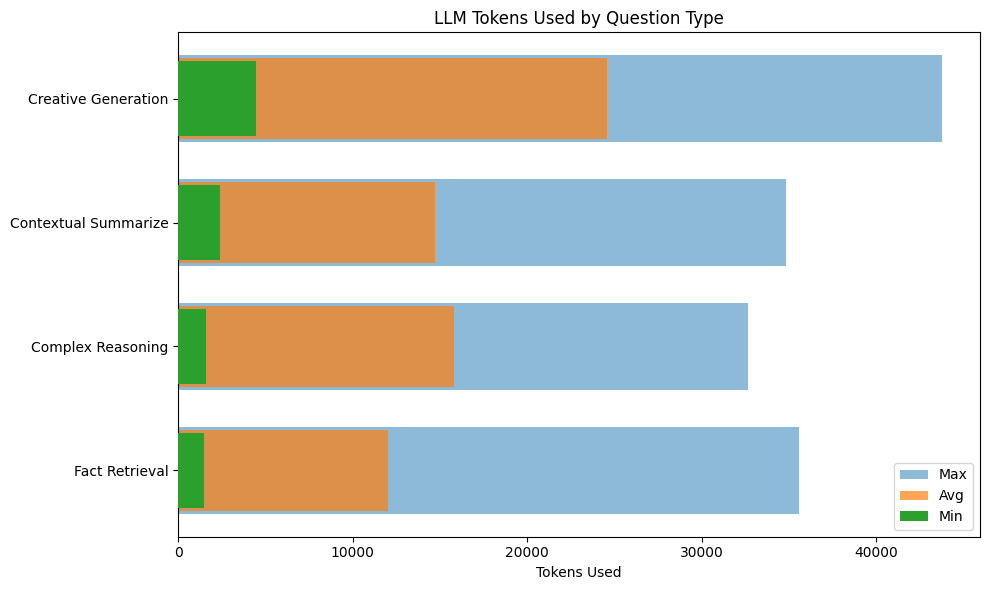

In [43]:
import matplotlib.pyplot as plt

x = ["Fact Retrieval", "Complex Reasoning", "Contextual Summarize", "Creative Generation"]

y1 = [min_retrieval, min_complex, min_summary, min_generation]
y2 = [avg_retrieval, avg_complex, avg_summary, avg_generation]
y3 = [max_retrieval, max_complex, max_summary, max_generation]

plt.figure(figsize=(10, 6))

plt.barh(x, y3, height=0.7, alpha=0.5, label="Max", zorder=1)
plt.barh(x, y2, height=0.65, alpha=0.7, label="Avg", zorder=2)
plt.barh(x, y1, height=0.6, alpha=1.0, label="Min", zorder=3)

plt.xlabel("Tokens Used")
plt.title("LLM Tokens Used by Question Type")

plt.yticks(fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()


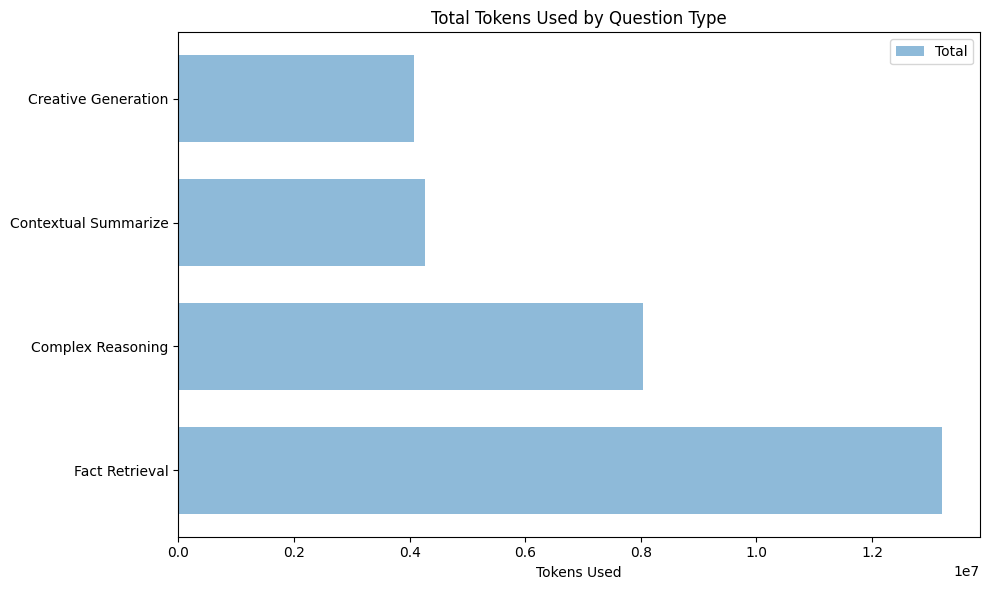

In [45]:
x = ["Fact Retrieval", "Complex Reasoning", "Contextual Summarize", "Creative Generation"]
y = [total_retrieval, total_complex, total_summary, total_generation]


plt.figure(figsize=(10, 6))
plt.barh(x, y, height=0.7, alpha=0.5, label="Total", zorder=1)

plt.xlabel("Tokens Used")
plt.title("Total Tokens Used by Question Type")

plt.yticks(fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()


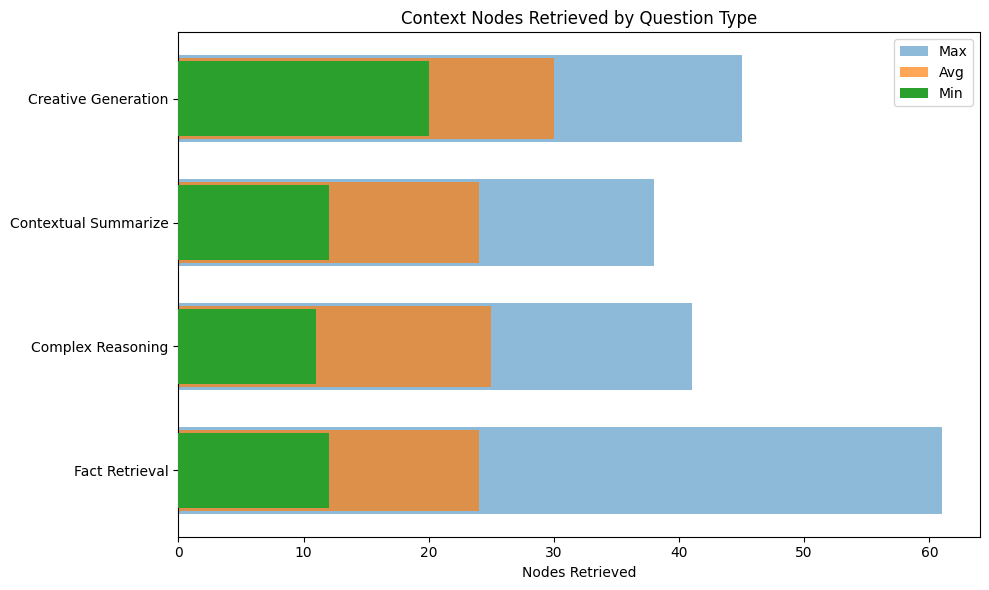

In [55]:
import matplotlib.pyplot as plt

x = ["Fact Retrieval", "Complex Reasoning", "Contextual Summarize", "Creative Generation"]

y1 = [min_nodes_retrieval, min_nodes_complex, min_nodes_summary, min_nodes_generation]
y2 = [avg_nodes_retrieval, avg_nodes_complex, avg_nodes_summary, avg_nodes_generation]
y3 = [max_nodes_retrieval, max_nodes_complex, max_nodes_summary, max_nodes_generation]

plt.figure(figsize=(10, 6))

plt.barh(x, y3, height=0.7, alpha=0.5, label="Max", zorder=1)
plt.barh(x, y2, height=0.65, alpha=0.7, label="Avg", zorder=2)
plt.barh(x, y1, height=0.6, alpha=1.0, label="Min", zorder=3)

plt.xlabel("Nodes Retrieved")
plt.title("Context Nodes Retrieved by Question Type")

plt.yticks(fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()


In [62]:
fact_retrieval_evaluated = pd.read_parquet("data/evaluations/fact_retrieval_evaluated.parquet")
fact_retrieval_evaluated = fact_retrieval_evaluated.merge(medical_questions_answered_loaded[["id", "question", "answer", "LLM_answer"]], left_on="qid", right_on="id", how="left")
fact_retrieval_evaluated.drop(columns=["id"], inplace=True)
fact_retrieval_evaluated

,qid,accuracy,rouge,tokens,question,answer,LLM_answer
0,Medical-73586ddc,0.996453,0.774194,1799,What is the most common type of skin cancer?,Basal cell carcinoma (BCC) is the most common ...,"Basal cell skin cancer, also known as basal ce..."
1,Medical-a8bad1cf,0.724107,0.620690,6419,From which cell type does basal cell carcinoma...,Basal cell carcinoma arises from basal cells i...,Basal cell carcinoma arises when basal cells i...
2,Medical-422500d5,0.727680,0.480000,7103,Which anatomical locations are most commonly a...,BCC most commonly develops in sun-exposed area...,Basal cell carcinoma most commonly affects sun...
3,Medical-6d2a190d,0.603060,0.190476,2423,What is the primary risk factor for basal cell...,UV radiation exposure is a primary risk factor...,The primary risk factor for basal cell carcino...
4,Medical-5ad931db,0.444778,0.264151,2763,How does fair skin affect the risk of developi...,Fair skin increases the risk of BCC.,Fair skin increases the risk of developing Bas...
...,...,...,...,...,...,...,...
1093,Medical-329de573,0.468845,0.100000,4088,What should be discussed before starting breas...,Fertility preservation should be discussed bef...,"Before starting breast cancer treatment, indiv..."
1094,Medical-e79a7e61,0.427511,0.200000,5180,What patient factor is considered in treatment...,Performance status is considered in treatment ...,Patient factors considered in treatment planni...
1095,Medical-883feb97,0.929114,0.131579,7368,What does follow-up for breast cancer include?,"Follow-up includes imaging, physical exams, an...","For breast cancer, follow-up and surveillance ..."
1096,Medical-53f6f364,0.668135,0.684211,5972,Which breast cancer subtype commonly presents ...,Inflammatory breast cancer (IBC) commonly pres...,Inflammatory breast cancer (IBC) commonly pres...


In [69]:
avg_fact_retrieval_accuracy = fact_retrieval_evaluated['accuracy'].mean()

print("Average Accuracy:", round(avg_fact_retrieval_accuracy, 4))
print("Average Rouge:", round(fact_retrieval_evaluated['rouge'].mean(), 4))
print("Total tokens used:", f"{fact_retrieval_evaluated['tokens'].sum():,}")

Average Accuracy: 0.6439
Average Rouge: 0.3595
Total tokens used: 4,228,024


In [ ]:
complex_reasoning_evaluated = pd.read_parquet("data/evaluations/complex_reasoning_evaluated.parquet")
complex_reasoning_evaluated = complex_reasoning_evaluated.merge(medical_questions_answered_loaded[["id", "question", "answer", "LLM_answer"]], left_on="qid", right_on="id", how="left")
complex_reasoning_evaluated.drop(columns=["id"], inplace=True)
complex_reasoning_evaluated

,qid,accuracy,rouge,context_recall,tokens,question,answer,LLM_answer
0,Medical-604c9d44,0.780004,0.156250,1.0,20295,Why is a patient with fair skin and a history ...,Because both fair skin and immune suppression ...,A patient with fair skin is at a higher risk f...
1,Medical-df366063,0.609812,0.168675,1.0,21629,If a patient presents with a shiny bump on the...,"A medical and family history, physical and ski...",To evaluate for basal cell carcinoma when a pa...
2,Medical-0a90f1f2,0.355934,0.123457,1.0,30825,How does the management of recurrent basal cel...,Management of recurrence depends on risk and r...,Initial basal cell skin cancer is highly treat...
3,Medical-831bb1e6,0.206992,0.235294,1.0,17044,Which combination of risk factors should promp...,"A combination of older age, fair skin, and fam...",The provided text identifies several risk fact...
4,Medical-01e3a9ea,0.868037,0.191489,0.0,29070,Why might a patient with a shiny bump and a hi...,Because radiation therapy is a risk factor for...,A patient with a shiny bump and a history of r...
...,...,...,...,...,...,...,...,...
504,Medical-1eda4787,0.532697,0.360656,1.0,27983,Which patients with breast cancer should recei...,All patients of reproductive potential should ...,"Patients with breast cancer, regardless of gen..."
505,Medical-24f2e8ea,0.418402,0.196078,1.0,34002,How does the presence of HER2 positivity alter...,HER2 positivity adds HER2-targeted therapy to ...,"For invasive breast cancer, HER2 positivity al..."
506,Medical-d1a87cb4,0.815916,0.144928,1.0,16114,What combination of clinical findings and diag...,Symptoms like bone pain or neurological sympto...,Metastatic breast cancer (Stage IV) is indicat...
507,Medical-311d66d6,0.593845,0.181818,1.0,34292,Which risk factors should be evaluated in a pa...,"Family history, BRCA1/2 mutations, and assigne...",When evaluating a patient with a new breast lu...


In [70]:
avg_complex_reasoning_accuracy = complex_reasoning_evaluated['accuracy'].mean()

print("Average Accuracy:", round(avg_complex_reasoning_accuracy, 4))
print("Average Rouge:", round(complex_reasoning_evaluated['rouge'].mean(), 4))
print("Average Context Recall:", round(complex_reasoning_evaluated['context_recall'].mean(), 4))
print("Total tokens used:", f"{complex_reasoning_evaluated['tokens'].sum():,}")

Average Accuracy: 0.6529
Average Rouge: 0.267
Average Context Recall: 0.8317
Total tokens used: 10,835,150


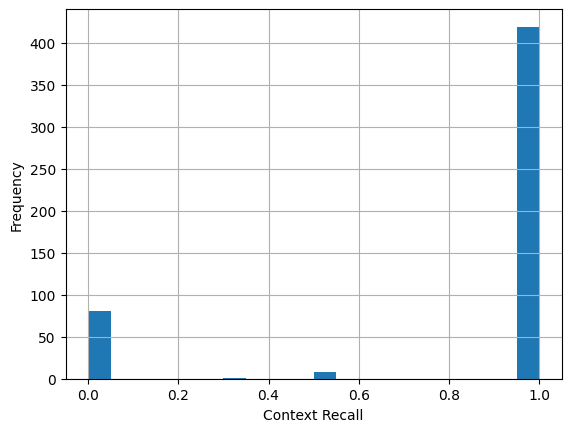

In [82]:
complex_reasoning_evaluated["context_recall"].hist(bins=20)
plt.xlabel("Context Recall")
plt.ylabel("Frequency")
plt.show()

In [ ]:
contextual_summarization_evaluated = pd.read_parquet("data/evaluations/contextual_summarization_evaluated.parquet")
contextual_summarization_evaluated = contextual_summarization_evaluated.merge(medical_questions_answered_loaded[["id", "question", "answer", "LLM_answer"]], left_on="qid", right_on="id", how="left")
contextual_summarization_evaluated.drop(columns=["id"], inplace=True)
contextual_summarization_evaluated

,qid,accuracy,coverage,tokens,context_recall,question,answer,LLM_answer
0,Medical-5fd3c02d,0.897562,0.800000,21577,1.0,What are the main risk factors associated with...,The main risk factors associated with the deve...,The main risk factors for developing basal cel...
1,Medical-b8b22d33,0.799240,0.666667,13468,1.0,Which anatomical locations and cell types are ...,Basal cell carcinoma arises from basal cells i...,Basal cell carcinoma (BCC) most commonly invol...
2,Medical-9c85110b,0.856499,0.785714,17508,1.0,What are the typical symptoms and presentation...,Basal cell carcinoma (BCC) typically presents ...,Basal cell carcinoma (BCC) typically appears i...
3,Medical-fcf87025,0.613506,0.800000,15275,1.0,Which diagnostic methods are used to confirm b...,Diagnosis of basal cell carcinoma involves a t...,The diagnostic process for basal cell carcinom...
4,Medical-6baf8bff,0.630592,0.210526,32147,1.0,What are the standard treatment options for ba...,The standard treatment options for basal cell ...,Standard treatment options for basal cell carc...
...,...,...,...,...,...,...,...,...
284,Medical-0cba5d0a,0.604894,0.583333,28478,1.0,What are the main risk factors and considerati...,The main risk factors for breast cancer includ...,Key risk factors for breast cancer include bei...
285,Medical-d72d7cb9,0.400845,0.000000,33129,1.0,How is follow-up and surveillance conducted fo...,Follow-up for breast cancer patients includes ...,"I am sorry, but the provided context does not ..."
286,Medical-97d64c1f,0.863777,0.750000,19773,1.0,What is the clinical significance of tumor gra...,The clinical significance of tumor grade in br...,Tumor grade in breast cancer is clinically sig...
287,Medical-4dc06fbd,0.581375,0.666667,24079,1.0,What are the most common therapies used in the...,Systemic therapies for breast cancer include c...,The most common systemic therapies used in bre...


In [ ]:
avg_contextual_summarization_accuracy = contextual_summarization_evaluated['accuracy'].mean()

print("Average Accuracy:", round(avg_contextual_summarization_accuracy, 4))
print("Average Coverage:", round(contextual_summarization_evaluated['coverage'].mean(), 4))
print("Average Context Recall:", round(contextual_summarization_evaluated['context_recall'].mean(), 4))
print("Total tokens used:", f"{contextual_summarization_evaluated['tokens'].sum():,}")

Average Accuracy: 0.663
Average Rouge: 0.5919
Average Context Recall: 0.8171
Total tokens used: 7,688,765


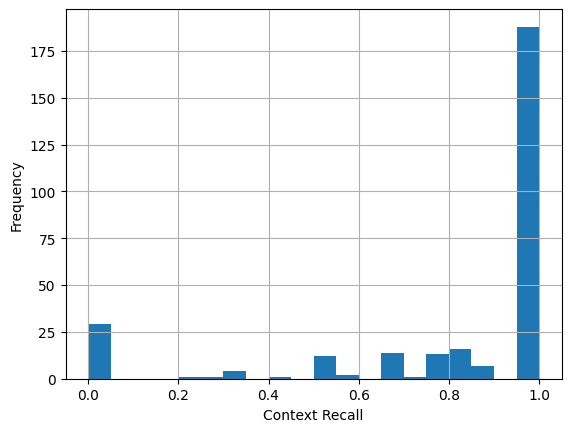

In [83]:
contextual_summarization_evaluated["context_recall"].hist(bins=20)
plt.xlabel("Context Recall")
plt.ylabel("Frequency")
plt.show()

In [65]:
creative_generation_evaluated = pd.read_parquet("data/evaluations/creative_generation_evaluated.parquet")
creative_generation_evaluated = creative_generation_evaluated.merge(medical_questions_answered_loaded[["id", "question", "answer", "LLM_answer"]], left_on="qid", right_on="id", how="left")
creative_generation_evaluated.drop(columns=["id"], inplace=True)
creative_generation_evaluated

,qid,accuracy,coverage,faithfulness,context_recall,tokens,question,answer,LLM_answer
0,Medical-fe3240a4,0.561742,0.416667,0.827586,1.000000,73951,Imagine you are a dermatology attending receiv...,Consult Note:\n\nA new patient was referred fo...,**Patient:** [Patient Name]\n**Reason for Cons...
1,Medical-8f5233d5,0.730521,0.800000,0.500000,1.000000,84377,You are a general practitioner drafting a disc...,Discharge Summary:\n\nDiagnosis: Basal cell ca...,**Patient Name:** [Patient Name]\n**Date of Bi...
2,Medical-c9c108e1,0.740913,0.785714,0.982456,0.888889,86880,Assume the role of a patient who has just been...,"Dear Family,\n\nI wanted to let you know that ...","Dear Family,\n\nI'm writing to let you know th..."
3,Medical-bf68d23e,0.676038,0.785714,0.838710,0.800000,52169,Rewrite the following scenario into a public h...,Public Health Advisory: Increased Basal Cell C...,**Community Health Advisory: Basal Cell Carcin...
4,Medical-fd1b07be,0.531412,0.500000,0.555556,0.875000,89725,You are a dermatology intern preparing a refer...,Referral Letter to Oncology:\n\nDear Colleague...,The patient presents with recurrent basal cell...
...,...,...,...,...,...,...,...,...,...
161,Medical-83c906e0,0.730450,0.550000,0.619048,0.900000,94522,You are an oncologist preparing a referral let...,"Dear Multidisciplinary Team,\n\nI am referring...",This 45-year-old woman has been diagnosed with...
162,Medical-d168a555,0.689004,0.208333,0.866667,0.846154,83975,Imagine you are a medical intern tasked with w...,Discharge Summary:\n\nDiagnosis: Stage III inf...,**Diagnosis:**\nPatient was diagnosed with Inf...
163,Medical-fe801cec,0.541114,0.571429,0.888889,0.666667,56951,You are a patient advocate tasked with draftin...,Public Health Notice: Protect Yourself—Know th...,## Public Health Notice: Understanding Breast ...
164,Medical-9210668e,0.585756,0.111111,0.957447,0.941176,94212,Transform the clinical facts on metastatic bre...,SOAP Progress Note\n\nSubjective: The patient ...,**S: Subjective**\nPatient reports distress an...


In [73]:
avg_creative_generation_accuracy = creative_generation_evaluated['accuracy'].mean()

print("Average Accuracy:", round(avg_creative_generation_accuracy, 4))
print("Average Coverage:", round(creative_generation_evaluated['coverage'].mean(), 4))
print("Average Faithfulness:", round(creative_generation_evaluated['faithfulness'].mean(), 4))
print("Average Context Recall:", round(creative_generation_evaluated['context_recall'].mean(), 4))
print("Total tokens used:", f"{creative_generation_evaluated['tokens'].sum():,}")

Average Accuracy: 0.6099
Average Coverage: 0.4129
Average Faithfulness: 0.8184
Average Context Recall: 0.8665
Total tokens used: 12,732,861


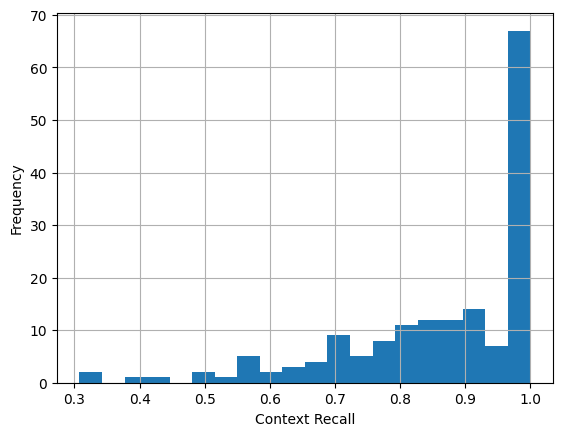

In [84]:
creative_generation_evaluated["context_recall"].hist(bins=20)
plt.xlabel("Context Recall")
plt.ylabel("Frequency")
plt.show()

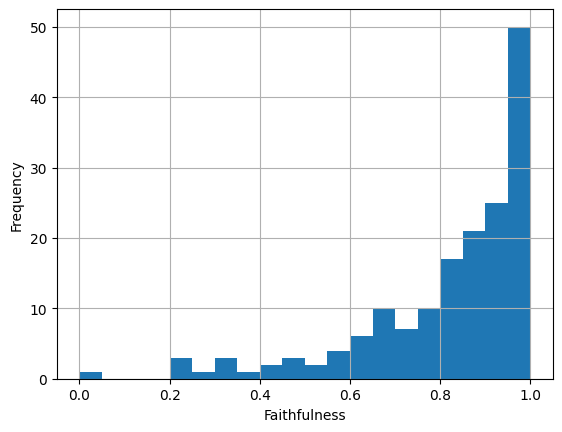

In [78]:
creative_generation_evaluated["faithfulness"].hist(bins=20)
plt.xlabel("Faithfulness")
plt.ylabel("Frequency")
plt.show()

In [80]:
avg_accuracy = (avg_fact_retrieval_accuracy * len(fact_retrieval_evaluated) + avg_complex_reasoning_accuracy * len(complex_reasoning_evaluated) + avg_contextual_summarization_accuracy * len(contextual_summarization_evaluated) + avg_creative_generation_accuracy * len(creative_generation_evaluated)) / len(medical_questions_answered_loaded)
print("Overall Average Accuracy:", round(avg_accuracy, 4))

Overall Average Accuracy: 0.6461
